# Operator Benchmarks

Each row checks forward and backward correctness against `TorchOpsBackend`, then reports forward/backward p50 latency, p95 latency, peak CUDA memory delta, and speedup versus torch.


In [1]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "minitrain").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "tests"))

from minitrain.model.ops import get_ops_backend
from operator_bench_utils import BenchCase, bench_sweep, plot_kernel_grid, to_summary_dataframe

torch.manual_seed(0)
assert torch.cuda.is_available(), "operator benchmarks require CUDA"

DEVICE = torch.device("cuda")
DTYPE = torch.float16
PROVIDERS = ("torch", "triton", "cuda")
WARMUP_MS = 25
REP_MS = 100
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS = (
    "fwd_p50_ms",
    "fwd_p95_ms",
    "fwd_peak_mem_mb",
    "fwd_speedup",
    "bwd_p50_ms",
    "bwd_p95_ms",
    "bwd_peak_mem_mb",
    "bwd_speedup",
)

print(torch.__version__)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
NVIDIA GeForce RTX 3050 Laptop GPU


Each kernel section now provides `make_case(size)` and `forward(provider, tensors)`. The runner owns tensor cloning, forward/backward correctness, timing, memory measurement, and cleanup. Cleanup clears the torch-created tensor dictionary before releasing the CUDA cache.

In [2]:
def run_kernel(kernel, sizes, size_label, make_case, forward):
    rows = bench_sweep(
        kernel=kernel,
        providers=PROVIDERS,
        sizes=sizes,
        size_label=size_label,
        make_case=make_case,
        forward=forward,
        warmup_ms=WARMUP_MS,
        rep_ms=REP_MS,
    )
    display(to_summary_dataframe(rows))
    plot_kernel_grid(rows, metrics=METRICS, save_path=FIG_DIR / f"{kernel}_summary.png")
    return rows


## RMSNorm

Sweep parameter: `rows`.

X-axis: activation tensor elements, `rows * hidden`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rmsnorm,torch,16384,ok,True,True,0.000000,0.000000,0.033792,0.034816,0.125000,1.000000,0.601696,1.178685,0.250000,1.000000
1,rmsnorm,triton,16384,ok,True,True,0.001953,0.015625,0.006144,0.006144,0.031738,5.500000,0.342048,0.449280,0.080078,1.759098
2,rmsnorm,torch,32768,ok,True,True,0.000000,0.000000,0.027648,0.029696,0.250000,1.000000,0.592896,1.148366,0.500000,1.000000
3,rmsnorm,triton,32768,ok,True,True,0.001953,0.015625,0.005120,0.006144,0.062988,5.400000,0.376368,0.509910,0.142578,1.575309
4,rmsnorm,torch,65536,ok,True,True,0.000000,0.000000,0.028672,0.030720,0.500000,1.000000,0.541584,1.111806,0.999512,1.000000
5,rmsnorm,triton,65536,ok,True,True,0.003906,0.031250,0.007168,0.008192,0.125977,4.000000,0.410000,0.644198,0.267578,1.320937
6,rmsnorm,torch,131072,ok,True,True,0.000000,0.000000,0.035840,0.037888,1.000000,1.000000,0.535056,1.071229,1.998047,1.000000
7,rmsnorm,triton,131072,ok,True,True,0.003906,0.031250,0.008192,0.009216,0.251953,4.375000,0.351744,0.446720,0.517578,1.521152
8,rmsnorm,torch,262144,ok,True,True,0.000000,0.000000,0.052224,0.054272,2.000000,1.000000,0.573440,0.982923,3.995117,1.000000
9,rmsnorm,triton,262144,ok,True,True,0.001953,0.062500,0.011264,0.011264,0.503906,4.636364,0.397440,0.644352,1.017578,1.442834


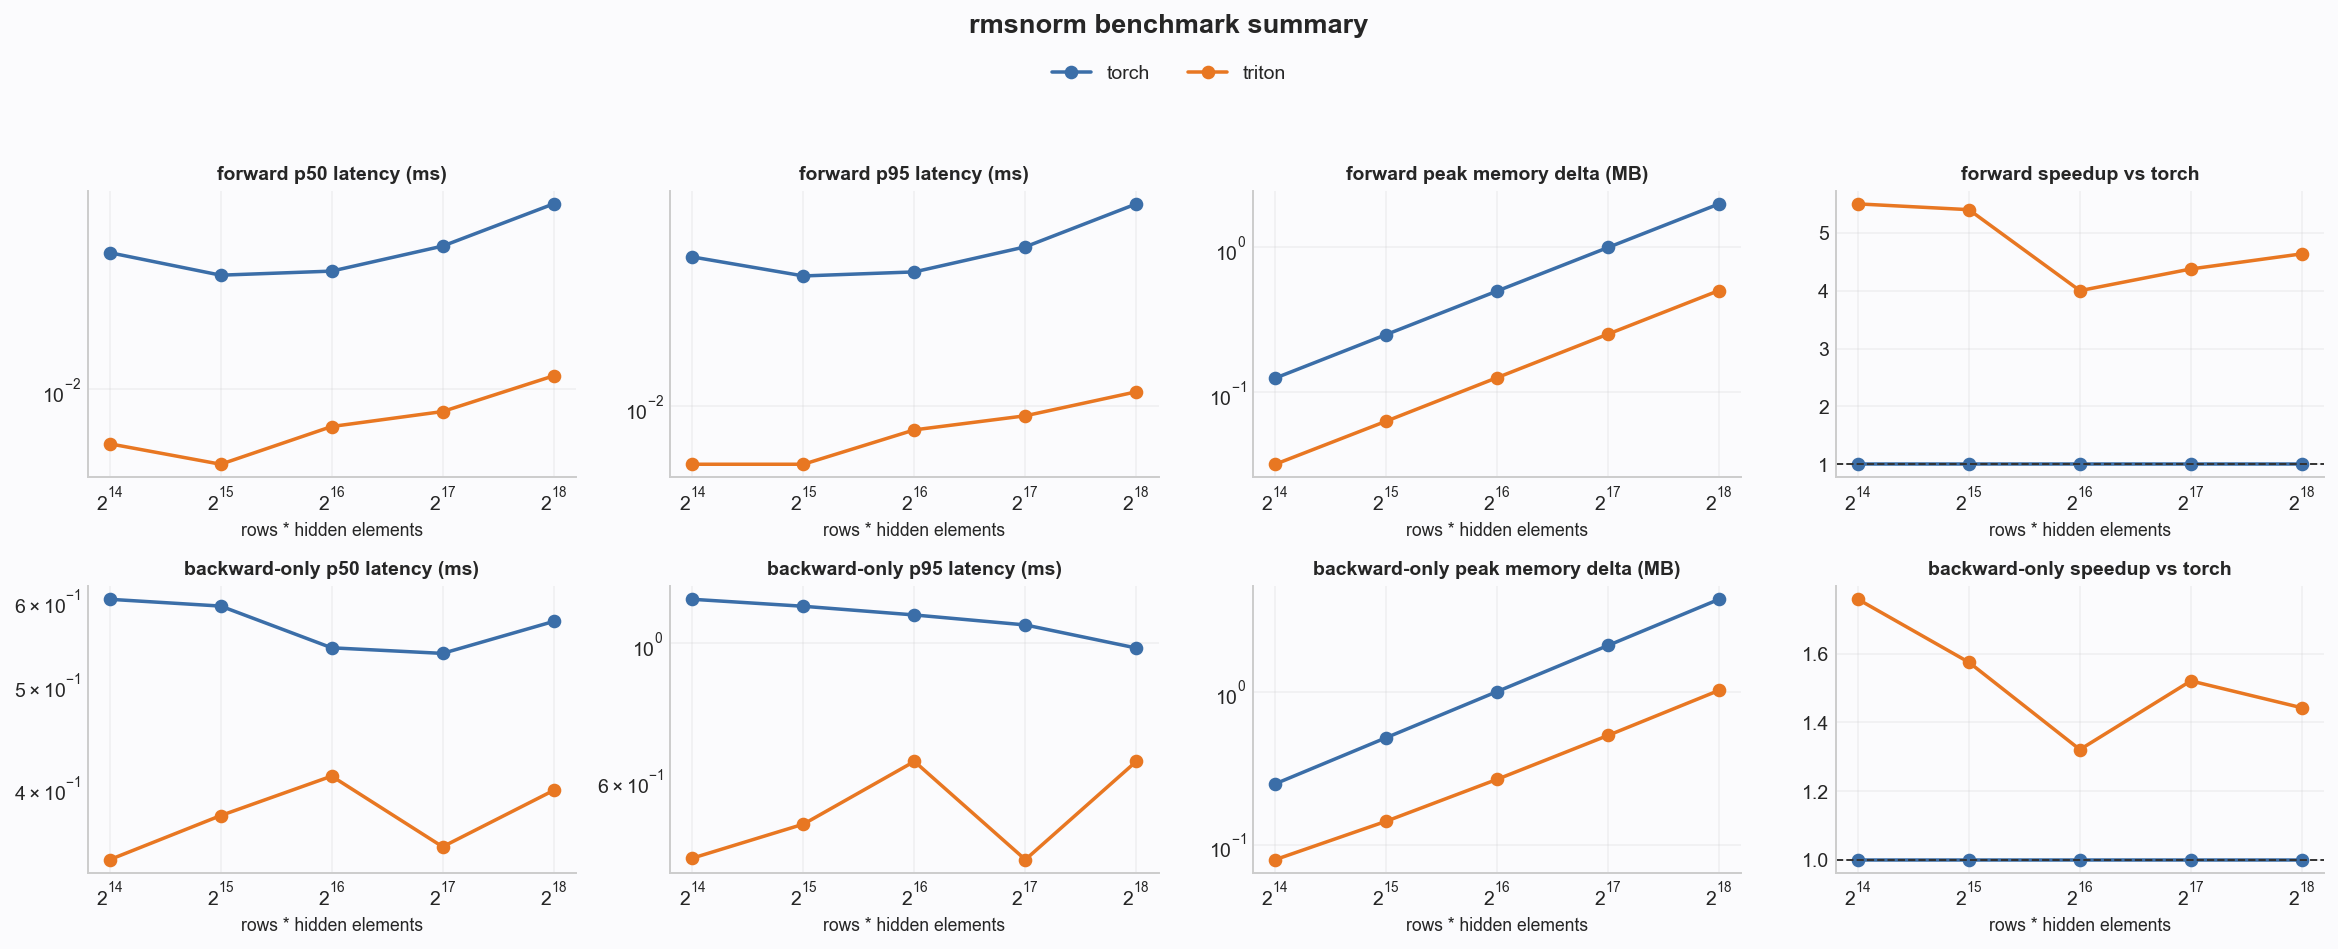

In [3]:
PROVIDERS = ("torch", "triton")
def make_rmsnorm_case(size):
    hidden = 256
    rows = size // hidden
    return BenchCase(
        tensors={
            "x": torch.randn(rows, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.ones(hidden, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("x", "weight"),
    )


def rmsnorm_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rmsnorm(tensors["x"], tensors["weight"], 1e-5)


rmsnorm_sizes = [256 * rows for rows in (64, 128, 256, 512, 1024)]
rmsnorm_rows = run_kernel(
    "rmsnorm",
    rmsnorm_sizes,
    "rows * hidden elements",
    make_rmsnorm_case,
    rmsnorm_forward,
)

## RoPE

Sweep parameter: `seq`.

X-axis: Q+K tensor elements, `2 * batch * heads * seq * head_dim`.

In [ ]:
def rope_cache(seq, dim):
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=DEVICE).float() / dim))
    freqs = torch.outer(torch.arange(seq, device=DEVICE).float(), inv_freq)
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos().to(dtype=DTYPE), emb.sin().to(dtype=DTYPE)


def make_rope_case(size):
    batch, heads, head_dim = 1, 4, 64
    seq = size // (2 * batch * heads * head_dim)
    cos, sin = rope_cache(seq, head_dim)
    return BenchCase(
        tensors={
            "q": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "cos": cos,
            "sin": sin,
        },
        grad_names=("q", "k"),
    )


def rope_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rope(tensors["q"], tensors["k"], tensors["cos"], tensors["sin"])


rope_sizes = [2 * 1 * 4 * seq * 64 for seq in (32, 64, 128, 256, 512)]
rope_rows = run_kernel("rope", rope_sizes, "Q + K elements", make_rope_case, rope_forward)


## SwiGLU

Sweep parameter: `rows`.

X-axis: input tensor elements, `2 * rows * intermediate` for gate and up.

In [ ]:
def make_swiglu_case(size):
    intermediate = 512
    rows = size // (2 * intermediate)
    return BenchCase(
        tensors={
            "gate": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
            "up": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("gate", "up"),
    )


def swiglu_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.swiglu(tensors["gate"], tensors["up"])


swiglu_sizes = [2 * rows * 512 for rows in (64, 128, 256, 512, 1024)]
swiglu_rows = run_kernel(
    "swiglu",
    swiglu_sizes,
    "gate + up elements",
    make_swiglu_case,
    swiglu_forward,
)


## CrossEntropy

Sweep parameter: `tokens`.

X-axis: logits tensor elements, `tokens * vocab`.

In [ ]:
def make_cross_entropy_case(size):
    vocab = 1024
    tokens = size // vocab
    return BenchCase(
        tensors={
            "logits": torch.randn(tokens, vocab, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("logits",),
    )


def cross_entropy_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.cross_entropy(tensors["logits"], tensors["targets"])


cross_entropy_sizes = [tokens * 1024 for tokens in (64, 128, 256, 512, 1024)]
cross_entropy_rows = run_kernel(
    "cross_entropy",
    cross_entropy_sizes,
    "tokens * vocab logits elements",
    make_cross_entropy_case,
    cross_entropy_forward,
)


## FusedLinearCrossEntropy

Sweep parameter: `vocab`.

X-axis: logical logits elements, `tokens * vocab`. This is the tensor a fused implementation tries not to materialize.

In [ ]:
def make_fused_linear_ce_case(size):
    tokens, hidden = 128, 256
    vocab = size // tokens
    return BenchCase(
        tensors={
            "x": torch.randn(tokens, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.randn(vocab, hidden, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("x", "weight"),
    )


def fused_linear_ce_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.fused_linear_cross_entropy(tensors["x"], tensors["weight"], tensors["targets"])


fused_linear_ce_sizes = [128 * vocab for vocab in (512, 1024, 2048, 4096, 8192)]
fused_linear_ce_rows = run_kernel(
    "fused_linear_cross_entropy",
    fused_linear_ce_sizes,
    "tokens * vocab logical logits elements",
    make_fused_linear_ce_case,
    fused_linear_ce_forward,
)
